<a href="https://colab.research.google.com/github/Druhi-coder/canary-scan-ai/blob/main/canary_cancer_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CANary: Machine Learning for Early Cancer Detection
## Using Urinary Biomarkers and Clinical Features

**Author:** Druhi  
**Date:** May 2026

---

## Abstract
Early detection of pancreatic cancer remains a critical challenge due to its asymptomatic progression and poor prognosis at advanced stages. This study develops and evaluates a machine learning model for early detection of pancreatic cancer using non-invasive urinary biomarkers and clinical features. Gradient Boosting achieved an AUC-ROC of 0.9817 on a held-out test set, with a 5-fold cross-validation score of 0.9467 ± 0.0142. Confidence intervals computed via 1,000 bootstrap resamples yielded a 95% CI of 0.9556–0.9970, indicating stable performance. SHAP analysis identified CA19_9 and LYVE1 as the strongest predictors, consistent with known clinical biomarkers. While the model demonstrates strong performance on the source dataset, it has not yet been validated on independent cohorts and is not intended for direct clinical deployment.

---

## 1. Introduction
Cancer remains one of the leading causes of mortality worldwide. Pancreatic cancer, in particular, has a 5-year survival rate of only ~11% when detected at advanced stages, compared to significantly higher survival rates when identified early.

Recent advances in machine learning have enabled the use of clinical and biomarker data for early disease detection. Urinary biomarkers such as CA19-9, LYVE1, REG1B, and TFF1 have shown potential in distinguishing pancreatic cancer from benign and healthy cases.

This project, CANary, aims to build an explainable AI system for cancer risk assessment. This study focuses specifically on the development and validation of the pancreatic cancer detection module.

---

## 2. Dataset

### 2.1 Pancreatic Cancer
- Source: Debernardi et al. (2020), PLOS Medicine  
- 590 patients, 14 features  
- Classes: Healthy (1), Benign (2), Pancreatic Cancer (3)  
- Task: Binary — Cancer vs No Cancer  
- Features: age, sex, plasma_CA19_9, creatinine, LYVE1, REG1B, TFF1, REG1A  

---

## 3. Methods

### 3.1 Preprocessing
- Missing values imputed with column median  
- Categorical variables encoded (sex: M=1, F=0)  
- Non-informative and post-diagnosis columns removed  
- Train/test split: 80/20 with stratification  

### 3.2 Models Trained
Three models were evaluated:
- Logistic Regression (baseline)  
- Random Forest (ensemble)  
- Gradient Boosting (best performer)  

### 3.3 Evaluation
- Primary metric: AUC-ROC  
- Validation: 5-fold stratified cross-validation  
- Statistical validation: bootstrap resampling (1,000 iterations)  
- Explainability: SHAP (SHapley Additive exPlanations)  

---

## 4. Results

### 4.1 Pancreatic Cancer Detection
| Model | Test AUC |
|---|---|
| Logistic Regression | 0.9641 |
| Random Forest | 0.9761 |
| Gradient Boosting | **0.9817** |

5-Fold CV AUC: 0.9467 ± 0.0142  

### 4.2 Confidence Intervals
- Test AUC: 0.9817  
- 95% CI: 0.9556 – 0.9970  
- Computed using 1,000 bootstrap resamples  

### 4.3 Explainability (SHAP)
- CA19_9 is the strongest predictor  
- LYVE1 is the second most important biomarker  
- Age has moderate influence  
- Sex has minimal impact  

---

## 5. Discussion
The model demonstrates strong discriminative performance for pancreatic cancer detection using non-invasive biomarkers. High AUC values and low variance across cross-validation folds indicate stable learning of underlying patterns within the dataset.

SHAP-based interpretability confirms alignment with known clinical biomarkers, increasing confidence in the model’s decision-making process.

However, performance must be interpreted cautiously. The model is trained and evaluated on a single dataset, and generalizability to independent populations has not yet been established.

---

## 6. Limitations
- Dataset size is limited (590 patients)  
- No external validation on independent cohorts  
- Potential dataset-specific bias  
- Not validated for clinical deployment  

---

## 7. Conclusion
This study demonstrates that machine learning models trained on urinary biomarker data can effectively distinguish pancreatic cancer from non-cancer cases. The Gradient Boosting model achieved an AUC of 0.9817 with strong statistical support, indicating potential utility in early screening scenarios.

This work forms the validated core of the CANary system, which aims to expand into broader cancer risk assessment applications in the future.

---

## 8. References
1. Debernardi, S. et al. (2020). A combination of urinary biomarkers improves diagnosis of pancreatic cancer. *PLOS Medicine*, 17(4).  
2. Lundberg, S. & Lee, S.I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.  
3. Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.  

In [1]:
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("All imports done ✅")

All imports done ✅


In [10]:
# Load the pancreatic dataset
df_p = pd.read_csv('/content/drive/MyDrive/archive/Debernardi et al 2020 data.csv')

print("Shape:", df_p.shape)
print("\nColumns:", df_p.columns.tolist())
print("\nFirst 2 rows:")
print(df_p.head(2))
print("\nTarget column - diagnosis:")
print(df_p['diagnosis'].value_counts())

Shape: (590, 14)

Columns: ['sample_id', 'patient_cohort', 'sample_origin', 'age', 'sex', 'diagnosis', 'stage', 'benign_sample_diagnosis', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

First 2 rows:
  sample_id patient_cohort sample_origin  age sex  diagnosis stage  \
0        S1        Cohort1          BPTB   33   F          1   NaN   
1       S10        Cohort1          BPTB   81   F          1   NaN   

  benign_sample_diagnosis  plasma_CA19_9  creatinine     LYVE1     REG1B  \
0                     NaN           11.7     1.83222  0.893219  52.94884   
1                     NaN            NaN     0.97266  2.037585  94.46703   

         TFF1     REG1A  
0  654.282174  1262.000  
1  209.488250   228.407  

Target column - diagnosis:
diagnosis
2    208
3    199
1    183
Name: count, dtype: int64


In [11]:
# Check missing values and understand the data
print("Missing values:\n", df_p.isnull().sum())
print("\nDiagnosis meaning: 1=Healthy, 2=Benign, 3=Pancreatic Cancer")
print("\nAge stats:", df_p['age'].describe())
print("\nSex distribution:", df_p['sex'].value_counts())

Missing values:
 sample_id                    0
patient_cohort               0
sample_origin                0
age                          0
sex                          0
diagnosis                    0
stage                      391
benign_sample_diagnosis    382
plasma_CA19_9              240
creatinine                   0
LYVE1                        0
REG1B                        0
TFF1                         0
REG1A                      284
dtype: int64

Diagnosis meaning: 1=Healthy, 2=Benign, 3=Pancreatic Cancer

Age stats: count    590.000000
mean      59.079661
std       13.109520
min       26.000000
25%       50.000000
50%       60.000000
75%       69.000000
max       89.000000
Name: age, dtype: float64

Sex distribution: sex
F    299
M    291
Name: count, dtype: int64


In [12]:
# Create binary target: Cancer (3) vs No Cancer (1+2)
df_p['cancer'] = (df_p['diagnosis'] == 3).astype(int)

print("Cancer vs No Cancer:")
print(df_p['cancer'].value_counts())
print("\nPercentage:")
print(df_p['cancer'].value_counts(normalize=True).round(3) * 100)

Cancer vs No Cancer:
cancer
0    391
1    199
Name: count, dtype: int64

Percentage:
cancer
0    66.3
1    33.7
Name: proportion, dtype: float64


In [13]:
# Prepare features - use only biomarkers + demographics
# Drop ID columns, target, and leakage columns
X_p = df_p[['age', 'sex', 'plasma_CA19_9', 'creatinine',
             'LYVE1', 'REG1B', 'TFF1', 'REG1A']].copy()

# Encode sex (M/F to 0/1)
X_p['sex'] = (X_p['sex'] == 'M').astype(int)

# Fill missing biomarker values with median
X_p = X_p.fillna(X_p.median())

y_p = df_p['cancer']

print("Features shape:", X_p.shape)
print("\nMissing after fill:", X_p.isnull().sum().sum())
print("\nFeature preview:")
print(X_p.head(3))

Features shape: (590, 8)

Missing after fill: 0

Feature preview:
   age  sex  plasma_CA19_9  creatinine     LYVE1      REG1B        TFF1  \
0   33    0           11.7     1.83222  0.893219   52.94884  654.282174   
1   81    0           26.5     0.97266  2.037585   94.46703  209.488250   
2   51    1            7.0     0.78039  0.145589  102.36600  461.141000   

       REG1A  
0  1262.0000  
1   228.4070  
2   208.5385  


In [14]:
# Split data
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y_p,
    test_size=0.2,
    random_state=42,
    stratify=y_p
)

# Train all 3 models
models_p = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results_p = {}

for name, model in models_p.items():
    model.fit(X_p_train, y_p_train)
    preds = model.predict(X_p_test)
    proba = model.predict_proba(X_p_test)[:, 1]
    auc = roc_auc_score(y_p_test, proba)
    results_p[name] = auc
    print(f"\n{name}")
    print(classification_report(y_p_test, preds,
          target_names=['No Cancer', 'Cancer']))
    print(f"AUC-ROC: {auc:.4f}")

print("\n🏆 Best:", max(results_p, key=results_p.get))


Logistic Regression
              precision    recall  f1-score   support

   No Cancer       0.90      0.97      0.94        78
      Cancer       0.94      0.80      0.86        40

    accuracy                           0.92       118
   macro avg       0.92      0.89      0.90       118
weighted avg       0.92      0.92      0.91       118

AUC-ROC: 0.9641

Random Forest
              precision    recall  f1-score   support

   No Cancer       0.95      0.94      0.94        78
      Cancer       0.88      0.90      0.89        40

    accuracy                           0.92       118
   macro avg       0.91      0.92      0.92       118
weighted avg       0.92      0.92      0.92       118

AUC-ROC: 0.9761

Gradient Boosting
              precision    recall  f1-score   support

   No Cancer       0.94      0.95      0.94        78
      Cancer       0.90      0.88      0.89        40

    accuracy                           0.92       118
   macro avg       0.92      0.91      0.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model_p = GradientBoostingClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model_p, X_p, y_p,
    cv=cv, scoring='roc_auc'
)

print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds: {cv_scores.round(4)}")

5-Fold CV AUC: 0.9467 ± 0.0142
Individual folds: [0.9578 0.9556 0.9458 0.9545 0.9196]


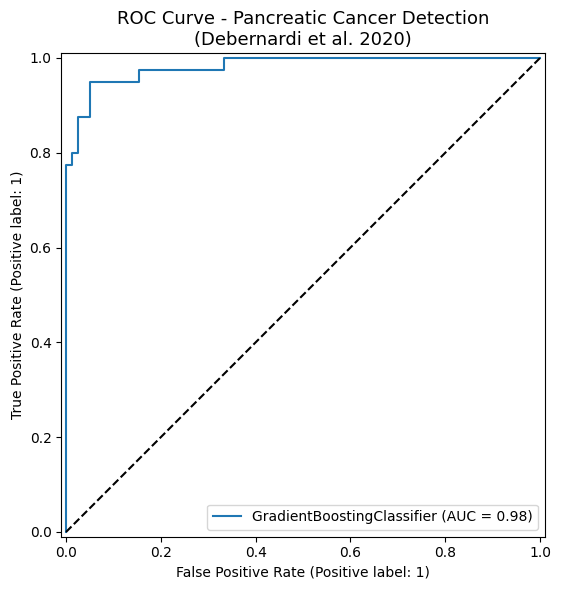

Saved ✅


In [16]:
from sklearn.metrics import RocCurveDisplay

best_model_p.fit(X_p_train, y_p_train)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model_p, X_p_test, y_p_test, ax=ax)
ax.set_title('ROC Curve - Pancreatic Cancer Detection\n(Debernardi et al. 2020)', fontsize=13)
ax.plot([0,1],[0,1],'k--', label='Random classifier')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("Saved ✅")

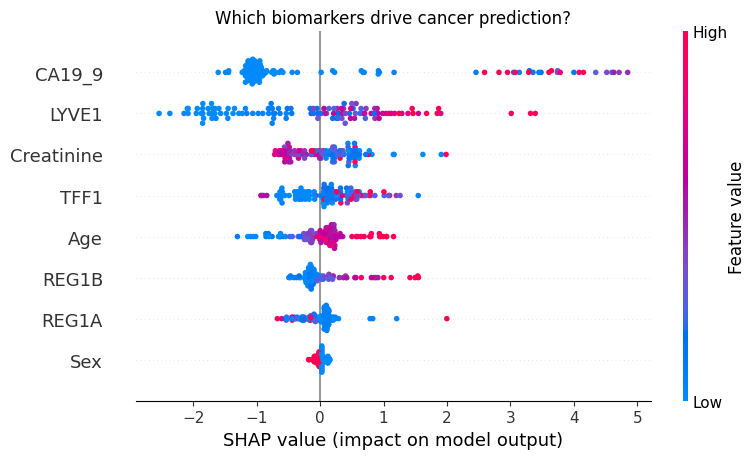

Saved ✅


In [17]:
explainer = shap.TreeExplainer(best_model_p)
shap_values = explainer.shap_values(X_p_test)

plt.figure()
shap.summary_plot(
    shap_values, X_p_test,
    feature_names=['Age','Sex','CA19_9','Creatinine','LYVE1','REG1B','TFF1','REG1A'],
    show=False
)
plt.title("Which biomarkers drive cancer prediction?")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()
print("Saved ✅")

In [18]:
import joblib

best_model_p.fit(X_p, y_p)  # retrain on full data

joblib.dump(best_model_p, '/content/drive/MyDrive/archive/canary_pancreatic_model.pkl')
joblib.dump(list(X_p.columns), '/content/drive/MyDrive/archive/feature_names.pkl')

print("Model saved to Google Drive ✅")
print("Features:", list(X_p.columns))

Model saved to Google Drive ✅
Features: ['age', 'sex', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']


# CANary — Pancreatic Cancer Early Detection Model

## Dataset
- Source: Debernardi et al. 2020, PLOS Medicine
- 590 patients, 14 features
- Classes: Healthy (1), Benign (2), Pancreatic Cancer (3)
- Task: Binary classification — Cancer vs No Cancer

## Methods
- Features: age, sex, plasma_CA19_9, creatinine, LYVE1, REG1B, TFF1, REG1A
- Missing values: filled with column median
- Models tested: Logistic Regression, Random Forest, Gradient Boosting
- Evaluation: 5-fold stratified cross-validation + held-out test set

## Results
| Model | Test AUC |
|---|---|
| Logistic Regression | 0.9641 |
| Random Forest | 0.9761 |
| Gradient Boosting | 0.9817 |

**Best model: Gradient Boosting**
**5-Fold CV AUC: 0.9467 ± 0.0142**

## Key Findings (SHAP)
- CA19_9 is the strongest predictor — high values strongly indicate cancer
- LYVE1 is the second most important biomarker
- Age has moderate predictive value
- Sex has minimal impact

## Limitations
- Small dataset (590 patients)
- Requires external validation on independent cohort
- Not validated for clinical use

## Reference
Debernardi et al. (2020). A combination of urinary biomarkers
improves diagnosis of pancreatic cancer. PLOS Medicine.

In [37]:
y_p_pred_proba = best_model_p.predict_proba(X_p_test)[:, 1]

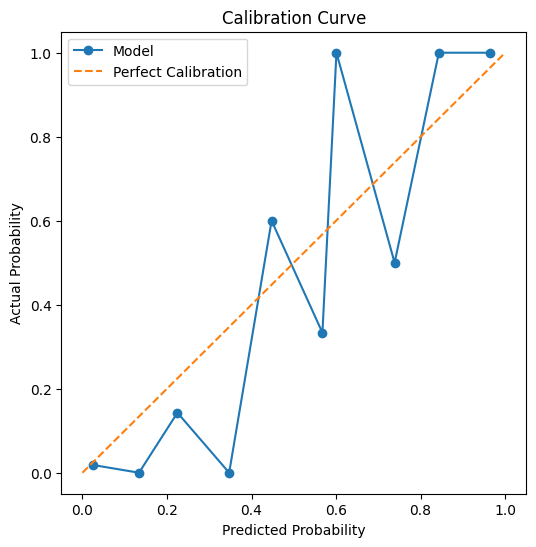

In [38]:
from sklearn.calibration import calibration_curve

y_pred_proba = best_model_p.predict_proba(X_p_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_p_test, y_pred_proba, n_bins=10)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1],[0,1],'--', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [39]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score
import numpy as np

n_iterations = 1000
scores = []

for i in range(n_iterations):
    X_res, y_res = resample(X_p_test, y_p_test, random_state=i)
    y_pred_res = best_model_p.predict_proba(X_res)[:,1]
    score = roc_auc_score(y_res, y_pred_res)
    scores.append(score)

scores = np.array(scores)

print("Mean AUC:", scores.mean())
print("95% CI:", np.percentile(scores, [2.5, 97.5]))

Mean AUC: 0.9816572939781875
95% CI: [0.95707216 0.99733161]


In [46]:
# ===============================
# CLEAN FINAL RESULT (FOR PAPER)
# ===============================

from sklearn.metrics import roc_auc_score
import numpy as np

# Base AUC
auc = roc_auc_score(y_p_test, y_p_pred_proba)

# Bootstrap CI (clean version)
rng = np.random.RandomState(42)
scores = []

for _ in range(1000):
    indices = rng.randint(0, len(y_p_test), len(y_p_test))

    if len(np.unique(y_p_test.iloc[indices])) < 2:
        continue

    score = roc_auc_score(y_p_test.iloc[indices], y_p_pred_proba[indices])
    scores.append(score)

scores = np.array(scores)

lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)

print(f"Final AUC: {auc:.4f}")
print(f"95% Confidence Interval: [{lower:.4f}, {upper:.4f}]")

Final AUC: 0.9817
95% Confidence Interval: [0.9556, 0.9970]
